In [1]:
token = "0_1D7een2oVstB7_UOzYwx8feVUsh3k0a9H0GqaaH7IgklbJqSELb7eKopLrxEl!" # M2M token from ERAS 

In [2]:
import ee
import geemap
# Authenticate
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='ee-anna-lackner')
print(ee.String('Hello from the Earth Engine servers!').getInfo())

Hello from the Earth Engine servers!


# acessing and understnading Google earth engine

In [40]:


# convert code snippet to python
js_snippet = """
// Define an area of interest geometry with a global non-polar extent.
var aoi = ee.Geometry.Polygon(
  [[[-179.0, 78.0], [-179.0, -58.0], [179.0, -58.0], [179.0, 78.0]]], null,
  false);

// Import hourly predicted temperature image collection for northern winter
// solstice. Note that predictions extend for 384 hours; limit the collection
// to the first 24 hours.
var tempCol = ee.ImageCollection('NOAA/GFS0P25')
  .filterDate('2018-12-22', '2018-12-23')
  .limit(24)
  .select('temperature_2m_above_ground');

// Define arguments for animation function parameters.
var videoArgs = {
  dimensions: 768,
  region: aoi,
  framesPerSecond: 7,
  crs: 'EPSG:3857',
  min: -40.0,
  max: 35.0,
  palette: ['blue', 'purple', 'cyan', 'green', 'yellow', 'red']
};

// Print the animation to the console as a ui.Thumbnail using the above defined
// arguments. Note that ui.Thumbnail produces an animation when the first input
// is an ee.ImageCollection instead of an ee.Image.
print(ui.Thumbnail(tempCol, videoArgs));

// Alternatively, print a URL that will produce the animation when accessed.
print(tempCol.getVideoThumbURL(videoArgs));
"""

geemap.js_snippet_to_py(js_snippet)




In [5]:
import ee

# Initialize the Earth Engine module.
ee.Initialize()

# Define an area of interest geometry with a global non-polar extent.
aoi = ee.Geometry.Polygon(
    [[[-179.0, 78.0], [-179.0, -58.0], [179.0, -58.0], [179.0, 78.0]]], None,
    False
)

# Import hourly predicted temperature image collection for northern winter
# solstice. Note that predictions extend for 384 hours; limit the collection
# to the first 24 hours.
tempCol = ee.ImageCollection('NOAA/GFS0P25') \
    .filterDate('2018-12-22', '2018-12-23') \
    .limit(24) \
    .select('temperature_2m_above_ground')

# Define arguments for animation function parameters.
videoArgs = {
    "dimensions": 768,
    "region": aoi,
    "framesPerSecond": 7,
    "crs": 'EPSG:3857',
    "min": -40.0,
    "max": 35.0,
    "palette": ['blue', 'purple', 'cyan', 'green', 'yellow', 'red']
}

# Get the URL for the animation.
video_url = tempCol.getVideoThumbURL(videoArgs)
print("Animation URL:", video_url)


Animation URL: https://earthengine.googleapis.com/v1/projects/ee-anna-lackner/videoThumbnails/daae03c90c7b9faaeb06796a49eaa400-45a0e8cd796733e917da4f904b60ee87:getPixels


In [4]:
catch_shp = "shapefile/example.shp"
catch = geemap.shp_to_ee(catch_shp)

m = geemap.Map()

dataset = ee.ImageCollection('LANDSAT/COMPOSITES/C02/T1_L2_8DAY_NDVI') \
.filterDate('2015-01-01', '2017-12-31') \
.filterBounds(catch.geometry())
colorized = dataset.select('NDVI')
colorizedVis = {
    "min": 0,
    "max": 1,
    "palette": [
    'ffffff', 'ce7e45', 'df923d', 'f1b555', 'fcd163', '99b718', '74a901',
    '66a000', '529400', '3e8601', '207401', '056201', '004c00', '023b01',
    '012e01', '011d01', '011301'
    ],
}
m.setCenter(18.834857,64.315246 , 8)
m.addLayer(colorized, colorizedVis, 'Colorized')
m.addLayer(catch, {}, "catch")

m

Map(center=[64.315246, 18.834857], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Sear…

In [16]:
import ee
import geemap

# Initialize Earth Engine
ee.Initialize()

# Load the catchment shapefile as an Earth Engine object.
catch_shp = "shapefile/example.shp"
catch = geemap.shp_to_ee(catch_shp)

# Define the map center to somewhere in Sweden and set zoom level.
m = geemap.Map(center=[64.315246, 18.834857], zoom=8)

# Load Landsat NDVI dataset and filter it over the catchment area for a specific date range.
dataset = ee.ImageCollection('LANDSAT/COMPOSITES/C02/T1_L2_8DAY_NDVI') \
    .filterDate('2021-01-01', '2022-12-31') \
    .filterBounds(catch.geometry()) \
    .select('NDVI')

# Define visualization parameters for NDVI.
colorizedVis = {
    "min": 0,
    "max": 1,
    "palette": [
        'ffffff', 'ce7e45', 'df923d', 'f1b555', 'fcd163', '99b718', '74a901',
        '66a000', '529400', '3e8601', '207401', '056201', '004c00', '023b01',
        '012e01', '011d01', '011301'
    ],
}

# Add layers to the map for visualization.
m.addLayer(dataset.median(), colorizedVis, 'NDVI Median')
m.addLayer(catch, {}, "Catchment Area")

# Define a smaller region, e.g., a 500,000-meter buffer around the catchment's centroid, with an error margin.

region = catch.geometry().centroid(maxError=10).buffer(5000).bounds().getInfo()['coordinates']


videoArgs = {
    "dimensions": 512,
    "region": region,  # Use the reduced region
    "framesPerSecond": 2,
    "crs": 'EPSG:3857',
    "min": 0,
    "max": 1,
    "palette": colorizedVis['palette']
}


# Generate the video thumbnail URL for the NDVI animation.
video_url = dataset.getVideoThumbURL(videoArgs)
print("NDVI Animation URL:", video_url)

# Display the map
m


NDVI Animation URL: https://earthengine.googleapis.com/v1/projects/ee-anna-lackner/videoThumbnails/b89faa7238eca3cc8cabfec457d54901-827c1f726c4a0de584642d70a33cbd70:getPixels


Map(center=[64.315246, 18.834857], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Sear…

# NDVI for Points

### Random fake input 

Sweden boundary has been saved as 'sweden_boundary.geojson'.


C:\Users\anlr0006\AppData\Local\Temp\ipykernel_38424\2126705382.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  sweden_boundary = sweden_gdf.geometry.unary_union


Random points saved locally as 'fake_input.shp'.


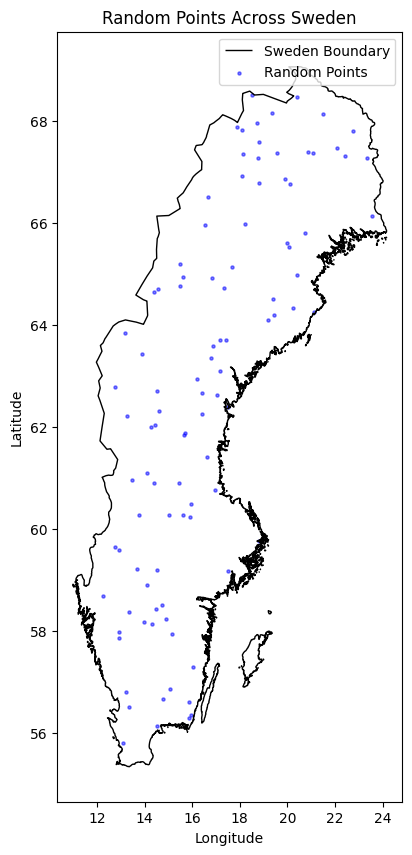

Map saved as 'sweden_random_points_map.png'.


In [26]:
import ee
import random
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import json

# Initialize the Earth Engine module
ee.Initialize()

# Step 1: Use GEE to fetch the Sweden boundary as GeoJSON
# Fetch the Sweden boundary from GEE
sweden = ee.FeatureCollection("FAO/GAUL/2015/level0").filter(ee.Filter.eq("ADM0_NAME", "Sweden"))

# Export the Sweden boundary as GeoJSON
sweden_geojson = sweden.geometry().getInfo()

# Save the GeoJSON to a local file (for later use in GeoPandas)
with open('sweden_boundary.geojson', 'w') as f:
    json.dump(sweden_geojson, f)

print("Sweden boundary has been saved as 'sweden_boundary.geojson'.")

# Step 2: Generate random points within the Sweden boundary using Python
# Load the Sweden boundary GeoJSON into GeoPandas
sweden_gdf = gpd.read_file('sweden_boundary.geojson')

# Get the boundary of Sweden
sweden_boundary = sweden_gdf.geometry.unary_union

# Function to generate random points within the boundary of Sweden
def generate_random_points(n, region):
    points = []
    min_lon, min_lat, max_lon, max_lat = region.bounds  # Get bounding box coordinates
    
    # Generate random points within the bounding box and check if they are inside Sweden
    while len(points) < n:
        lon = random.uniform(min_lon, max_lon)
        lat = random.uniform(min_lat, max_lat)
        point = Point(lon, lat)
        
        # Check if the point is within the Sweden boundary
        if region.contains(point):
            points.append((lon, lat))
    
    return points

# Generate 100 random points within Sweden's boundary
random_points = generate_random_points(100, sweden_boundary)

# Convert the random points to a GeoDataFrame and add sample identifier (idx)
points_gdf = gpd.GeoDataFrame(
    geometry=[Point(lon, lat) for lon, lat in random_points],
    crs="EPSG:4326"  # WGS84 coordinate system
)

# Add a unique sample identifier (idx) for each point
points_gdf['sample_id'] = points_gdf.index  # Use the index as the unique identifier

# Save the points as a shapefile
shapefile_name = "fake_input.shp"
points_gdf.to_file(shapefile_name, driver="ESRI Shapefile")
print(f"Random points saved locally as '{shapefile_name}'.")

# Step 3: Plot Sweden boundary and random points
fig, ax = plt.subplots(figsize=(10, 10))
sweden_gdf.boundary.plot(ax=ax, linewidth=1, color="black", label="Sweden Boundary")
points_gdf.plot(ax=ax, markersize=5, color="blue", alpha=0.5, label="Random Points")

# Customize plot appearance
ax.set_title("Random Points Across Sweden")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()

# Optionally, save the plot as an image
output_map_file = "sweden_random_points_map.png"
plt.savefig(output_map_file, format='png')

# Display the map
plt.show()

print(f"Map saved as '{output_map_file}'.")


## Finding NDVI for points in shapefile

In [38]:
import ee 
import pandas as pd
import geopandas as gpd
from datetime import datetime

# Initialize the Earth Engine API
ee.Initialize()

# Function to load the shapefile and convert it to a FeatureCollection
def geo_to_ee(gdf):
    features = []
    for idx, geometry in gdf.geometry.items():  # Use .items() instead of .iteritems()
        if geometry.geom_type == 'Polygon':
            ee_geom = ee.Geometry.Polygon(list(geometry.exterior.coords))
            features.append(ee.Feature(ee_geom).set('sample_id', idx))  # Add 'sample_id' as property
        elif geometry.geom_type == 'MultiPolygon':
            ee_geom = ee.Geometry.MultiPolygon([list(poly.exterior.coords) for poly in geometry])
            features.append(ee.Feature(ee_geom).set('sample_id', idx))  # Add 'sample_id' as property
        elif geometry.geom_type == 'Point':
            ee_geom = ee.Geometry.Point([geometry.x, geometry.y])
            features.append(ee.Feature(ee_geom).set('sample_id', idx))  # Add 'sample_id' as property
        else:
            print(f"Skipping unsupported geometry type: {geometry.geom_type}")
    return ee.FeatureCollection(features)

# Load the shapefile into a GeoDataFrame using geopandas
shapefile_path = 'shapefile/fake_input.zip'  # Replace with the correct path
gdf = gpd.read_file(shapefile_path)

# Convert the GeoDataFrame to an Earth Engine FeatureCollection
points = geo_to_ee(gdf)

# Load Sentinel-2 image collection
Sentinel2_L2A = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')

# Define the months for which you want to calculate the monthly median (January to December)
months = [
    "01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"
]

# Define the years for which you want to calculate the monthly median (2020 to 2021)
years = [2020, 2021]

# Function to generate the correct last day of the month (handling leap years)
def get_last_day_of_month(year, month):
    # Create a datetime object for the given month and year, then find the last day of the month
    if month == "02":  # Special handling for February (Leap Year)
        if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)):  # Leap year check
            return f"{year}-{month}-29"  # Leap year (February 29)
        else:
            return f"{year}-{month}-28"  # Non-leap year (February 28)
    elif month in ["04", "06", "09", "11"]:  # 30-day months
        return f"{year}-{month}-30"
    else:  # 31-day months
        return f"{year}-{month}-31"

# Function to apply cloud mask to Sentinel-2 images
def mask_clouds(image):
    # Sentinel-2 Cloud Masking (SCL band 9 - cloud/land mask)
    cloud_mask = image.select('SCL').eq(4).Or(image.select('SCL').eq(5))  # 4: Cloud, 5: Cirrus
    return image.updateMask(cloud_mask.Not())

# Function to calculate NDVI
def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

# Function to mask out edges of images
def mask_edges(image):
    # Sentinel-2 Edge Masking (using the SCL band to remove edges)
    edge_mask = image.select('SCL').neq(0)
    return image.updateMask(edge_mask)

# Store results in a list
results = []

# Loop through each month and collect images from all years, then compute the monthly median
for month in months:
    print(f"Processing month: {month}")
    
    # Filter images for the given month across all years
    image_collection = None
    for year in years:
        start_date = f"{year}-{month}-01"
        end_date = get_last_day_of_month(year, month)  # Get the correct last day of the month
        
        # Filter images for this specific month in the current year
        date_filter = ee.Filter.date(start_date, end_date)
        
        # Filter and prepare Sentinel-2 imagery for this month
        s2_filtered = Sentinel2_L2A \
            .filter(date_filter) \
            .filterBounds(points) \
            .map(mask_edges) \
            .select(['B2', 'B3', 'B4', 'B8A', 'B8', 'B7', 'B6', 'B5', 'B9', 'B11', 'B12', 'SCL'])
        
        # Apply cloud mask and calculate NDVI for each year/month image collection
        collection = s2_filtered.map(mask_clouds).map(add_ndvi)
        
        # Merge the collections for all years for the specific month
        if image_collection is None:
            image_collection = collection
        else:
            image_collection = image_collection.merge(collection)

    # Check how many images are available for the month across all years
    image_count = image_collection.size().getInfo()
    print(f"Number of images for {month}: {image_count}")
    
    # If no images are available for the month, skip this iteration
    if image_count == 0:
        print(f"No images for {month}. Skipping.")
        continue

    # Calculate the median NDVI for the given month across all years
    monthly_ndvi_median = image_collection.select('NDVI').median()

    # Reduce to median NDVI for each point in the shapefile
    median_ndvi_per_point = monthly_ndvi_median.reduceRegions(
        collection=points,
        reducer=ee.Reducer.median(),  # Use median instead of mean
        scale=50,  # Set the scale of the imagery (in meters)
        tileScale=2
    )

    try:
        # Get the results as a dictionary (list of dicts)
        median_ndvi_per_point_info = median_ndvi_per_point.getInfo()

        # Extract data and append to the results list
        for feature in median_ndvi_per_point_info['features']:
            feature_data = feature['properties']
            sample_id = feature['properties']['sample_id']
            coordinates = feature['geometry']['coordinates']

            feature_data['month'] = month  # Add month info
            feature_data['sample_id'] = sample_id  # Add sample_id
            feature_data['coordinates'] = coordinates  # Add coordinates

            results.append(feature_data)

    except Exception as e:
        print(f"Error computing median NDVI for {month}: {str(e)}")
        # If error occurs, append a None for the median NDVI and sample info
        for point in points.getInfo()['features']:
            feature_data = {
                'month': month,
                'NDVI': None,  # Set median NDVI to None if error occurs
                'sample_id': point['properties']['sample_id'],
                'coordinates': point['geometry']['coordinates']
            }
            results.append(feature_data)

# Convert results to a pandas DataFrame
df = pd.DataFrame(results)

df


Processing month: 01
Number of images for 01: 812
Processing month: 02
Number of images for 02: 1625
Processing month: 03
Number of images for 03: 1891
Processing month: 04
Number of images for 04: 1858
Processing month: 05
Number of images for 05: 1889
Processing month: 06
Number of images for 06: 1812
Processing month: 07
Number of images for 07: 1890
Processing month: 08
Number of images for 08: 1884
Processing month: 09
Number of images for 09: 1845
Processing month: 10
Number of images for 10: 1834
Processing month: 11
Number of images for 11: 1015
Processing month: 12
Number of images for 12: 424


,median,sample_id,month,coordinates
0,0.047238,0,01,"[16.425931471396066, 62.25481085400529]"
1,NaN,1,01,"[18.50997899122519, 68.50390614043296]"
2,0.059582,2,01,"[15.690028579526572, 61.88358210023475]"
3,-0.015983,3,01,"[13.188371760562084, 63.84207133084334]"
4,NaN,4,01,"[20.84638760537719, 67.39188244727912]"
...,...,...,...,...
1195,0.016535,95,12,"[15.01557217301675, 60.27003770081907]"
1196,NaN,96,12,"[18.81126420078492, 67.58663782510884]"
1197,NaN,97,12,"[16.223700490631177, 62.94450861399784]"
1198,0.071804,98,12,"[14.443150559299891, 62.04317810206681]"


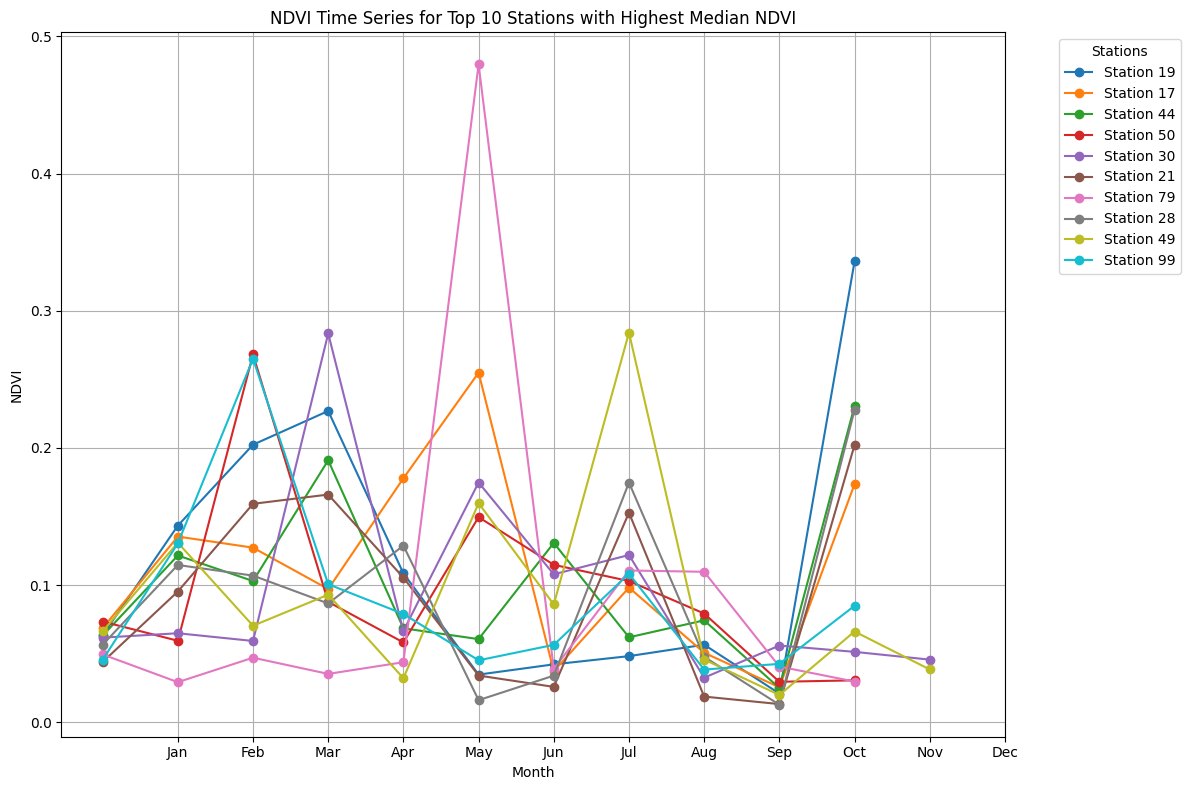

In [43]:
import matplotlib.pyplot as plt

# Compute the median NDVI for each station
station_medians = df.groupby('sample_id')['median'].mean().reset_index()

# Sort the stations by median NDVI in descending order and select the top 10
top_stations = station_medians.sort_values('median', ascending=False).head(10)['sample_id']

# Create the plot
plt.figure(figsize=(12, 8))

# Loop through the selected stations and plot their NDVI time series
for station in top_stations:
    station_data = df[df['sample_id'] == station]
    
    # Sort by month to ensure correct time series order
    station_data = station_data.sort_values('month')
    
    # Plotting each station's NDVI over time (from January to December)
    plt.plot(station_data['month'], station_data['median'], label=f"Station {station}", marker='o')

# Customize the plot
plt.title('NDVI Time Series for Top 10 Stations with Highest Median NDVI')
plt.xlabel('Month')
plt.ylabel('NDVI')
plt.xticks(ticks=range(1, 13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.legend(title="Stations", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

